# multi variable linear regression where we have multiple variables 

price = m1 * area + m2 * bedrooms + m3 * age +b 

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [4]:
df = pd.read_csv("homeprices_multivariant.csv")
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


# I checked the data so it needs to be cleaned 

In [14]:
df.bedrooms.median()
df.bedrooms.fillna(df.bedrooms.median())
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,4.0,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [19]:
reg = linear_model.LinearRegression()

reg.fit(df[["area","bedrooms","age"]],df.price)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
reg.predict([[3000,3,40]])

/Users/muhammadyasirkhan/Desktop/Personal/Github/ML-System-Builds/myenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([498408.25158031])

In [24]:
reg.coef_
reg.intercept_

np.float64(221323.00186540402)

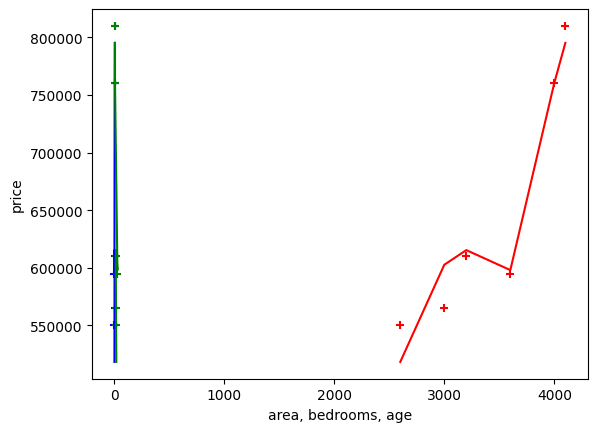

In [29]:
plt.xlabel("area, bedrooms, age")
plt.ylabel("price")
plt.scatter(df.area,df.price,color="red",marker="+")
plt.scatter(df.bedrooms,df.price,color="blue",marker="+")
plt.scatter(df.age,df.price,color="green",marker="+")

plt.plot(df.area,reg.predict(df[["area","bedrooms","age"]]),color="red")
plt.plot(df.bedrooms,reg.predict(df[["area","bedrooms","age"]]),color="blue")
plt.plot(df.age,reg.predict(df[["area","bedrooms","age"]]),color="green")